# 1. Introduction and dataset description
### 1.1 Data Overview

The **Dirty Cafe Sales** dataset used in this report was sourced from **Kaggle**. 
Source: [Kaggle - Cafe Sales - Dirty Data for Cleaning Training](https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training)

The **Dirty Cafe Sales** dataset, comprising **10,000 synthetic transactions**, was specifically selected for this analysis from **Kaggle**. While the data is generated, its value lies in its high fidelity to real-world business scenarios.

### The dataset is ideal for cleaning practice for:

* **Simulation of Real-World Data Fragmentation:** In a high-volume retail setting like a cafe, data integrity is often compromised by system glitches or human oversight. This dataset accurately mirrors these "information voids"—such as missing timestamps, unrecorded quantities, and null price fields—providing a realistic environment for practicing restorative cleaning techniques.
* **Focus on Data Imputation & Reconstruction:** Because the dataset relies on a structured menu (Item/Price), it offers a logical framework for complex cleaning. It allows us to move beyond simple row deletion and instead practice **intelligent imputation**: using business logic to reconstruct missing variables (e.g., deriving `Quantity` from `Total Spent` and `Price Per Unit`).
* **Technical Rigor in Preprocessing:** The "dirty" nature of the records—specifically the absence of critical sales attributes—forces a deep dive into the data preprocessing pipeline. It serves as a focused training ground for identifying null patterns, standardizing inconsistent formats, and ensuring the internal consistency of the record set.

Ultimately, this dataset was selected to demonstrate the technical proficiency required to transform raw, fragmented inputs into a coherent, high-quality data structure.


### 1.2 Orginal Feature Descriptions

The table below details the variables and the specific "noise" introduced in each column:

| Column Name | Description | Expected Type | Example / Issues |
| :--- | :--- | :--- | :--- |
| `Transaction ID` | Unique identifier for each transaction. | String | `TXN_1234567` |
| `Item` | Name of the item purchased. | Categorical | `Coffee`, `ERROR` |
| `Quantity` | Number of items bought. | Integer | `1`, `3`, `UNKNOWN` |
| `Price Per Unit` | Price for a single unit. | Float | `2.00`, missing values |
| `Total Spent` | Total transaction amount. | Float | Should be `Qty * Price` |
| `Payment Method`| Method used for payment. | Categorical | `Cash`, `None` |
| `Location` | Where the sale took place. | Categorical | `In-store`, `Takeaway` |
| `Transaction Date`| Date of purchase. | Datetime | `2023-01-01`, formatting errors |

*Specifically, the dataset includes the following menu items with their respective price ranges for further imputation:

| Item | Price ($) |
| :--- | :--- |
| Coffee | 2 |
| Tea | 1.5 |
| Sandwich | 4 |
| Salad | 5 |
| Cake | 3 |
| Cookie | 1 |
| Smoothie | 4 |
| Juice | 3 |

# 2. Cleaning and preprocessing steps

Following the initial data assessment, a structured three-step cleaning strategy has been developed to restore the integrity of the **Dirty Cafe Sales** dataset. This process focuses on type consistency and logical imputation.

### 2.1 Sequential Ordering and Standardization
The first priority is to establish a logical structure and a clean baseline for the records:
* **Sorting:** By sorting the dataset by `Transaction ID`, we can approximate a chronological order, which is essential for identifying patterns in missing date values. But the result turns out that there is no relationship betwwen IDs and dates, so we will deal with this later in **Step 2.5**.
* **Standardizing Missingness:** All inconsistent placeholders (such as "UNKNOWN", "ERROR", or empty strings) are replaced with `np.nan`. This ensures that Python’s pandas library can correctly identify and calculate missing data statistics in subsequent steps.

### 2.2 Data Type Uniformity
To ensure the dataset is ready for mathematical computation, we must enforce strict data type constraints:
* **Numerical Alignment:** Columns like `Quantity`, `Price Per Unit`, and `Total Spent` are cast to appropriate numeric types (`int` or `float`).
* **Temporal Consistency:** The `Transaction Date` column is converted into a standard `datetime` format to resolve any formatting inconsistencies introduced during data generation.

### 2.3 Reference-Based Imputation (Menu Mapping)
Using the provided **Menu Items Reference**, we perform "Intelligent Imputation" to recover missing numerical values:
* **`Price Per Unit` Recovery:** If the price is missing but the `Item` is known, we map the correct price from the reference table.

### 2.4 Cross-Column Logical Imputation

Following the reference-based mapping, we leverage the mathematical dependency between `Quantity`, `Price Per Unit`, and `Total Spent` to recover remaining missing values. This step ensures internal consistency across all financial records.

The imputation logic follows the formula:  
$$Total\ Spent = Quantity \times Price\ Per\ Unit$$

**The following restorative actions are performed:**

* **`Quantity` Reconstruction:** For transactions where the total expenditure and unit price are available, the missing quantity is derived by dividing `Total Spent` by `Price Per Unit`.
* **`Price Per Unit` Calculation:** In cases where the item was not found in the reference menu but the total spent and quantity are known, the unit price is back-calculated to fill the gap.
* **`Total Spent` Validation & Completion:** For records where both quantity and unit price are present but the total is missing, the `Total Spent` is populated by calculating their product.
### 2.5 Temporal Data Handling and Final Pruning

In this final stage of cleaning, we addressed the NaNs in the `Transaction Date` column. This step directly addresses the challenge identified in **Step 2.1** regarding the non-linear relationship between Transaction IDs and dates.

* **Re-evaluating Imputation Strategy:** We initially considered using the preceding transaction's date to fill missing values. However, as noted in **Step 2.1**, since Transaction IDs do not follow a strict chronological order, any form of "Forward Fill" would introduce artificial temporal errors and compromise the dataset's integrity.
* **Accuracy-Driven Data Removal:** Upon inspection, we determined that missing values in the `Transaction Date` column account for only **4.6%** of the total records. Given this low percentage, we opted to **directly drop these rows** to maintain 100% accuracy in our temporal data.
* **Index Reset:** Following the removal of these rows, the dataset's index was reset to ensure a continuous and clean sequence for the final cleaned version of the data.

By prioritizing precision over volume, we ensure that any subsequent time-series or trend analysis is based solely on verified historical timestamps.
### 2.6 Reverse-Logic Item Recovery

To further minimize data loss, we apply a reverse mapping logic based on the unique price points identified in **Step 2.3**.

* **Identification:** We isolate items with unique prices from the menu.
* **Retroactive Filling:** For any record where the `Item` is missing but the `Price Per Unit` matches one of these unique values, the corresponding item name is automatically restored.

### 2.7 Heuristic Reasoning for Edge Cases

After executing the automated cleaning pipelines, we conducted a manual investigation of the remaining null values. 

**Key Logical Deductions:**

* **Case 1: Unique Total Allocation (Index 6802)**
    A transaction with a `Total Spent` of **\$25.0** was identified. Based on our menu prices and item quantity limit, this total can *only* be achieved by purchasing **5 Salads (\$5.0 each)**. We manually restored the `Item`, `Quantity`, and `Price Per Unit` for this record.

* **Case 2: Price Point Inference (Index 82)**
    For a transaction totaling **\$9.0**, the only logical combination within the quantity constraints is **3 units of a \$3.0 item** (either Cake or Juice). While the specific item remains ambiguous, we restored the numerical `Price Per Unit` and `Quantity` to maintain the integrity of our financial totals.

### 2.8 Advanced Imputation via K-Nearest Neighbors (KNN)

For the remaining missing values in critical analytical fields—such as `Location`, `Payment Method`, `Quantity`, and `Price Per Unit`—we implemented a **KNN Imputer**, which leverages the "feature space" to find the most similar transactions and estimate missing values based on their nearest neighbors.

**The Advanced Imputation Pipeline:**

* **Feature Engineering for Context:** To enhance the imputer's performance, we decomposed the `Transaction Date` into `Month`, `Day`, and `Weekday`. This captures temporal patterns (e.g., specific items being more popular on weekends) to inform the KNN model.
* **Categorical Encoding & One-Hot Transformation:** - `Payment Method` and `Location` were factorized into numeric codes.
    - `Item` categories were converted via **One-Hot Encoding**, ensuring that the specific type of product purchased remains a heavy weight in the similarity calculation.
* **Constrained Numerical Restoration** - **Quantity:** Post-imputation values were rounded to the nearest integer.
    - **`Quantity Integrity`:** Since customers cannot purchase fractional items (e.g., 1.4 units), all imputed `Quantity` values are rounded to the nearest whole integer to reflect real-world transactions.
    - **`Price Consistency`:** Given the **reference menu**, imputed `Price Per Unit` values are "snapped" to the nearest valid price point from our menu (e.g., a predicted **\$1.42** is corrected to **\$1.50**). This eliminates "impossible prices" generated by the algorithm.
    - **Financial Reconciliation:** After restoring the base components, `Total Spent` was recalculated as $Quantity \times Price\ Per\ Unit$ to ensure 100% logical accuracy.
* **Categorical Decoding:** The numeric codes for Location and Payment Method were rounded and mapped back to their original text labels, successfully restoring the categorical narrative of each transaction.

By utilizing KNN, we transformed the remaining "information gaps" into statistically grounded data points, maximizing the dataset's utility for behavioral and revenue analysis.

### 2.9 Resolving Categorical Ambiguity via XGBoost Classification

In the final stage of our cleaning pipeline, we addressed the remaining missing values in the `Item` column. These gaps persisted because certain items share identical price points (e.g., **\$3.0** for both Cake and Juice, or **\$4.0** for Sandwich and Smoothie), making simple logical mapping impossible.

To resolve this ambiguity, we employed an **XGBoost (Extreme Gradient Boosting) Classifier** to predict the most likely item based on underlying transaction patterns.

**The Classification Strategy:**

* **Feature Selection:** The model utilizes the refined features generated in previous steps, including `Quantity`, `Price Per Unit`, `Month`, `Day`, `Weekday`, and encoded versions of `Payment Method` and `Location`.
* **Label Encoding:** The `Item` categories were transformed using a `LabelEncoder` to provide a numerical target for the XGBoost algorithm.
* **Supervised Learning:** - **Training Set:** Records with confirmed `Item` values were used to "teach" the model the relationships between transaction characteristics and specific products.
    * **Prediction:** For the ambiguous records, the model analyzed the feature context to assign the most statistically probable `Item` label.
* **Final Restoration:** Predicted labels were inverse-transformed back into their original text format, completing the categorical narrative for every row in the dataset.

### 2.10 Final Validation and Integrity Audit

To conclude the data cleaning process, we perform a rigorous two-tier validation to ensure that our automated and machine-learning-based imputations are both technically sound and business-accurate.

**1. Visualizing Completion - Heatmap Analysis：**
We generate the missingness heatmap. A uniform color across the entire plot confirms that 100% of the gaps in the dataset—originally affecting almost every column—have been successfully filled.
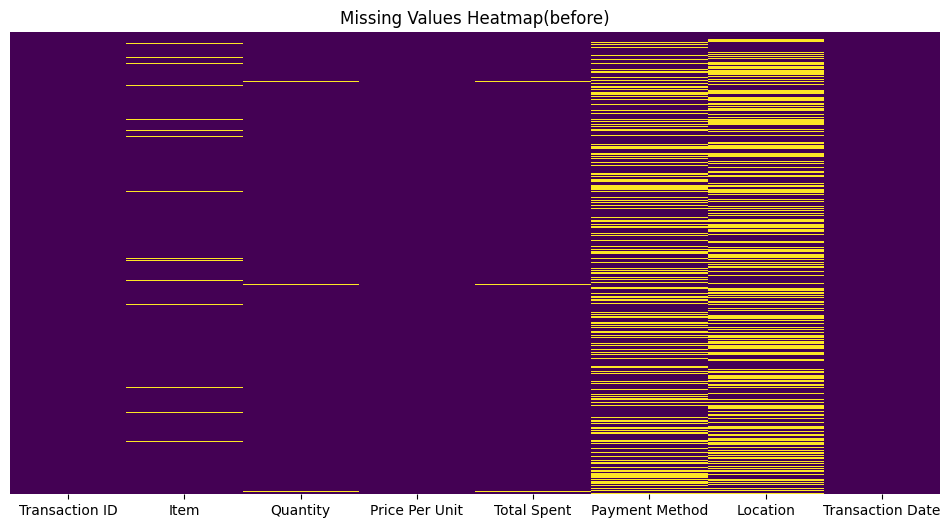
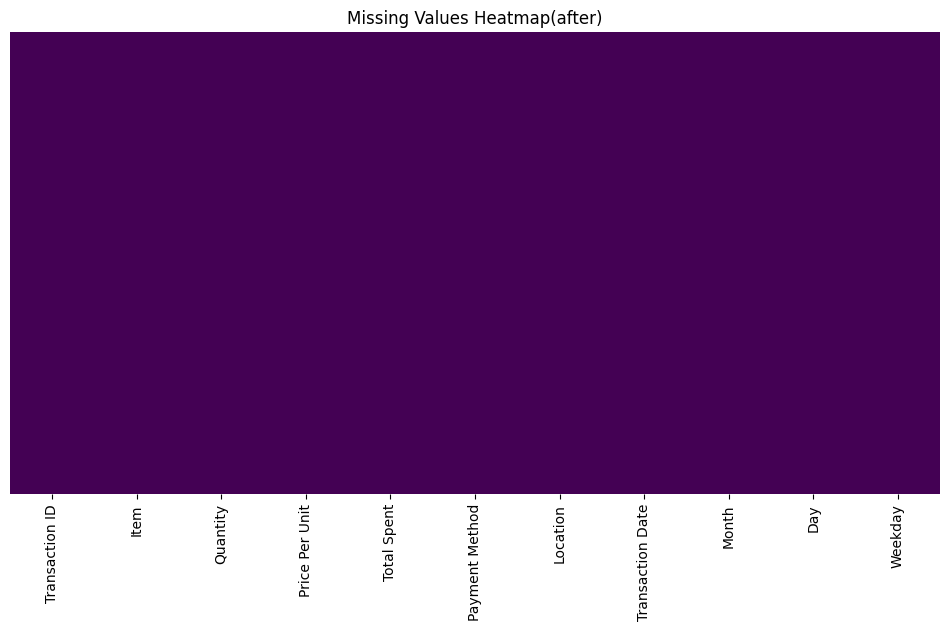

**2. Logical and Mathematical Verification：**
Beyond just filling the holes, we verify the "quality" of the restored data through two strict checks:

* **Menu Alignment Audit:** We cross-reference every record against our menu prices reference. This ensures that the KNN and XGBoost models haven't assigned an "impossible" price to an item (e.g., ensuring every 'Coffee' is exactly \$2.0; ensuring every price of each item is consistent with the menu).
* **Financial Equation Check:** We validate the fundamental accounting logic:  
    $$\text{Price Per Unit} \times \text{Quantity} = \text{Total Spent}$$
    By filtering for any delta greater than 0.01, we confirm that our rounding and recalculation steps have maintained perfect mathematical consistency.

**Conclusion:** The audit returned **"all Good!"**, signifying that the dataset is now pristine, logically consistent, and ready for high-level exploratory data analysis (EDA).

### 2.11 Feature Transformation via One-Hot Encoding

To finalize the dataset for regression analysis, we addressed the non-numeric nature of our categorical variables. i.e. We transformed our nominal variables into a machine-readable format using **One-Hot Encoding**.

**The Encoding Strategy:**

* **Target Variables:** We applied the encoding process to the key categorical features: `Item`, `Payment Method`, and `Location`.
* **Binary Expansion:** Each unique category within these features was transposed into its own binary column.

### 2.12 Final Dataset Overview & Structural Summary

With the cleaning pipeline and logical audits complete, this section provides a comprehensive snapshot of the finalized dataset, we transformed the dataset from "data preparation" to "analytical readiness," ensuring the structural integrity of all 9,540 records.

As shown below, the dataset now maintains 100% density across all 11 features, with synchronized data types for temporal and numerical analysis.

| # | Column | Non-Null Count | Dtype |
| :--- | :--- | :--- | :--- |
| 0 | **Transaction ID** | 9540 non-null | str |
| 1 | **Item** | 9540 non-null | str |
| 2 | **Quantity** | 9540 non-null | float64 |
| 3 | **Price Per Unit** | 9540 non-null | float64 |
| 4 | **Total Spent** | 9540 non-null | float64 |
| 5 | **Payment Method** | 9540 non-null | str |
| 6 | **Location** | 9540 non-null | str |
| 7 | **Transaction Date** | 9540 non-null | datetime64 | 
| 8 | **Month** | 9540 non-null | int32 |
| 9 | **Day** | 9540 non-null | int32 |
| 10 | **Weekday** | 9540 non-null | int32 |

***Note on Dimensionality:** While the summary above outlines the 11 core feature categories, the operational dataset used for modeling has been expanded via **OHE**. The categorical columns (`Item`, `Payment Method`, `Location`) were transformed into binary dummy variables (e.g., `Item_Coffee`, `Payment Method_Credit Card`), bringing the final column count to **18**.

# 3. Exploratory Data Analysis (EDA)

### 3.1 Summary statistics

#### Numerical variables
| Metric | Total Spent (USD) | Quantity | Price Per Unit (USD) |
| :--- | :---: | :---: | :---: |
| **Count** | 9540.00 | 9540.00 | 9540.00 |
| **Mean** | 8.92 | 3.02 | 2.95 |
| **Std Dev** | 6.00 | 1.42 | 1.28 |
| **Min** | 1.00 | 1.00 | 1.00 |
| **25% (Q1)** | 4.00 | 2.00 | 2.00 |
| **50% (Median)** | 8.00 | 3.00 | 3.00 |
| **75% (Q3)** | 12.00 | 4.00 | 4.00 |
| **Max** | 25.00 | 5.00 | 5.00 |

The mean of Total Spent is $8.92, while the median is $8.00. Since the mean is slightly higher than the median, the distribution is mildly right-skewed, likely due to a small number of high-value orders pulling the average upward. In contrast, the mean and median of quantity and price per unit are very close, suggesting that these variables are approximately symmetrically distributed. The median of quantity is 3.0, meaning that 50% of orders (approximately 4,770 transactions) include between one and three items. Additionally, 75% of total order amounts are below $12.00. This indicates that the majority of customers (75%) spend no more than $12 per order.

#### Categorical variables 

| Item | Frequency | Percentage |
| :--- | :---: | :---: | 
| **Coffee** | 1,249 | 13.09% | 
| **Juice** | 1,246 | 13.06% | 
| **Salad** | 1,217 | 12.76% | 
| **Cake** | 1,196 | 12.54% | 
| **Sandwich** | 1,181 | 12.38% | 
| **Smoothie** | 1,158 | 12.14% | 
| **Cookie** | 1,151 | 12.06% | 
| **Tea** | 1,142 | 11.97% | 
| **Total** | **9,540** | **100%** | 

The sales volume of each item is very similar, indicating that there is no single product that is significantly more or less popular than the others. Among them, coffee has a slightly higher sales share (13.09%), while tea has a relatively lower share (11.97%).

| Location | Frequency | Percentage |
| :--- | :---: | :---: | 
| **Takeaway** | 4,851 | 50.85% | 
| **In-store** | 4,689 | 49.15% | 

The proportion of in-store versus takeaway orders is also quite balanced, with roughly half of customers choosing to dine in and the other half opting for takeaway.

| Payment Method | Frequency | Percentage | 
| :--- | :---: | :---: |
| **Digital Wallet** | 4,657 | 48.82% | 
| **Credit Card** | 2,450 | 25.68% | 
| **Cash** | 2,433 | 25.50% | 

In terms of payment methods, approximately half of customers use a digital wallet, while credit card and cash payments each account for about one quarter of transactions.

### 3.2 Distributions, Relationships, and Trends

![Histogram](./figures/Distribution_Histogram.png)

The distribution plots of the numerical variables further validate our earlier findings. Total Spent shows a right-skewed, multimodal distribution. Most orders are concentrated in the lower spending range ($1.00–$12.00), while the long tail extends to approximately $25.00, indicating the presence of a small number of high-value transactions.

Quantity is distributed quite evenly across the five integer levels from 1 to 5, suggesting a relatively uniform purchasing pattern in terms of the number of items per order.



![Payment Method × Item](./figures/Payment_Method_Item.jpg)

This heatmap shows the proportion of each product within the total transaction volume of a given payment method.

Cash is most frequently used to purchase salad (0.14) and cake (0.14), while digital wallet has the highest share in coffee (0.14) purchases.Overall, the proportions across different payment methods fluctuate within a narrow range of 0.12 to 0.14, indicating that the store’s payment system is highly diversified. No single product is dominated by any particular payment method.

![Locations × Item](./figures/Items_Location.pic.jpg)

Nearly all products are distributed very close to a 50:50 split between Takeaway and In-store orders.

However, Cake, Coffee, Cookie, Salad, and Tea show slightly higher frequencies in the takeaway scenario. In contrast, items such as Sandwich, Juice, and Smoothie perform more strongly in the in-store setting, indicating a greater tendency for customers to consume these products on-site.

![Daily Total Revenue Over Time](./figures/Daily_Total_Revenue_Over_Time.jpg)

The figure above displays the daily total revenue for 2023. Since the dataset contains daily observations, it allows us to examine short-term fluctuations, long-term trends, and potential seasonal patterns. In overall, revenue appears to fluctuate around a relatively stable central level throughout the year. There is no clear upward or downward trend, nor any obvious seasonal pattern, suggesting the absence of a strong long-term trend.Despite this overall stability, the series exhibits substantial daily volatility. Daily revenue ranges approximately from 100 to 370. The frequent sharp peaks and troughs indicate that revenue is highly sensitive to short-term factors.

![Average Transaction Value By Month](./figures/Average_Transaction_Value_By_Month.jpg)

The figure above presents the average transaction value by month in 2023, which reflects the average spending per transaction. Over the past 12 months, the average transaction value fluctuated within a relatively narrow range of approximately 8.7 to 9.3. Month-to-month variation is minimal, with the difference between the highest and lowest months being less than one unit. Also, there is no sharp changes or structural breaks are observed, indicating that customers’ spending per transaction remained stable over time. Among all months, April recorded the highest average transaction value, while July had the lowest.


![Average Spending by Day of Week](./figures/average_spending_by_day_of_week.jpg)

The figure above shows the average spending by day of the week. Overall, average daily spending exhibits some variation, fluctuating within a range of approximately 8.7 to 9.2. Among all days, Tuesday records the highest average spending (around 9.2), while Wednesday has the lowest (around 8.7).Notably, weekend spending is not significantly higher than weekday levels. This suggests that the business is not primarily driven by weekend consumption. Instead, customer purchasing patterns appear to be more routine and consistent, reflecting everyday consumption rather than leisure-oriented spending.


![Item Distribution by Month](./figures/item_distribution_by_month.jpg)

The heatmap illustrates the proportion of total monthly sales attributed to each product category. Each cell represents the relative share of a specific item in a given month, with darker colors indicating a higher sales proportion for that item during that month. Among the products, cake shows a relatively higher sales share in September compared to other items. Meanwhile, coffee, juice, and sandwich each record higher proportions in October, December, and January, respectively. This suggests the presence of subtle monthly variations in product preferences across the year.


### 3.3  Patterns, Correlations, and Anomalies

![Correlation Matrix of Key Numerical Variables](./figures/correlation_matrix_of_key_numerical_variables.jpg)

The correlation matrix illustrates the linear relationships among four key numerical variables. Correlation coefficients range from –1 to 1, where values close to 1 indicate a strong positive relationship, values close to 0 indicate little to no linear relationship, and values close to –1 indicate a strong negative relationship.

As expected, total spend is positively correlated with both quantity and price per unit, since total spending naturally increases when customers purchase more items or higher-priced products.

In addition, the correlations with month are close to zero. This suggests the absence of a clear linear time trend. Revenue drivers remain stable across different months, with no structural growth or decline throughout the year. These findings are consistent with the results observed in the time series analysis.




![High Value Transaction in Total Spent](./figures/high_value_transactions_in_total_spent.jpg)

To examine potential outliers, a red dashed vertical line was added to the distribution plot of Total Spent, representing the 99th percentile cutoff. This threshold separates the top 1% of highest-spending transactions from the rest of the dataset. From a modeling perspective, extreme values can disproportionately influence mean-based models. Since outliers inflate variance and may distort parameter estimates, applying a log transformation can help stabilize the distribution, reduce skewness, and improve model robustness.


# Feature engineering process and justification

# Summary of key findings

# Challenges faced and future recommendations